In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt, log2

from itertools import product
from sklearn.datasets import load_breast_cancer, load_wine, load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import check_random_state

RNG = 42


In [53]:
datasets = []
for name, loader in [("breast_cancer", load_breast_cancer), ("wine", load_wine), ("digits", load_digits)]:
    X, y = loader(as_frame=True, return_X_y=True)
    datasets.append((name, X, y))


In [48]:
datasets = []
X_br, y_br = load_breast_cancer(return_X_y=True, as_frame=True)
datasets.append(("breast_cancer", X_br, y_br))

X_wi, y_wi = load_wine(return_X_y=True, as_frame=True)
datasets.append(("wine", X_wi, y_wi))

X_di, y_di = load_digits(return_X_y=True, as_frame=True) # harder
datasets.append(("digits", X_di, y_di))

In [49]:
X_br.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Investigate class imbalance

Name : target
1    357
0    212
Name: count, dtype: int64


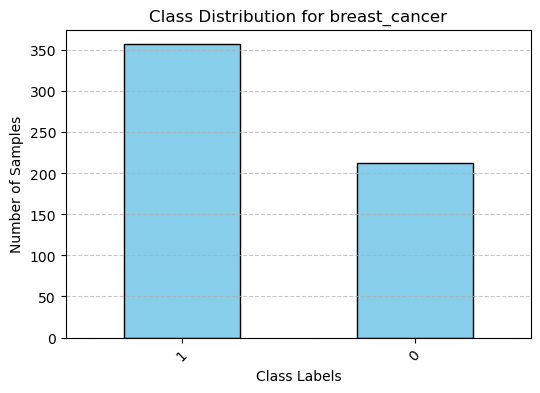

Name : target
1    71
0    59
2    48
Name: count, dtype: int64


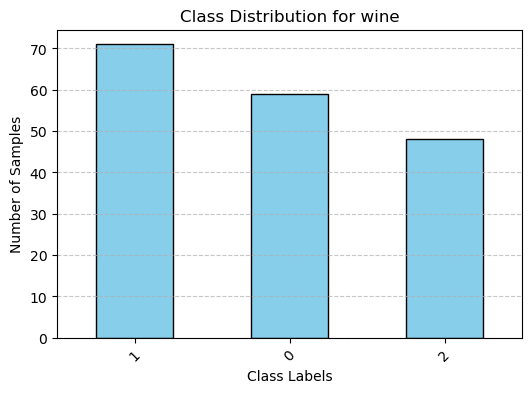

Name : target
3    183
1    182
5    182
4    181
6    181
9    180
7    179
0    178
2    177
8    174
Name: count, dtype: int64


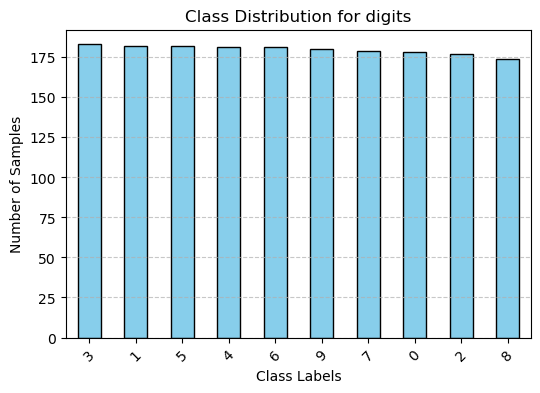

In [50]:
for Name, X, y in datasets:
    y_values = y.value_counts()
    print(f"Name : {y_values}")

    import matplotlib.pyplot as plt

    y_values = y.value_counts()

    plt.figure(figsize=(6,4))
    y_values.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title(f"Class Distribution for {Name}")
    plt.xlabel("Class Labels")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()


Investigate Tree Depth 

Fix the number of decision trees, num features that are randomly selected at each split and the bag size

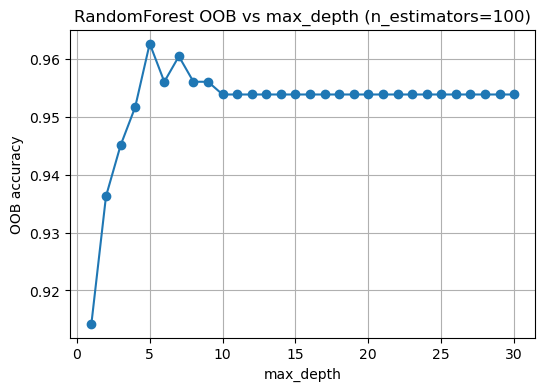

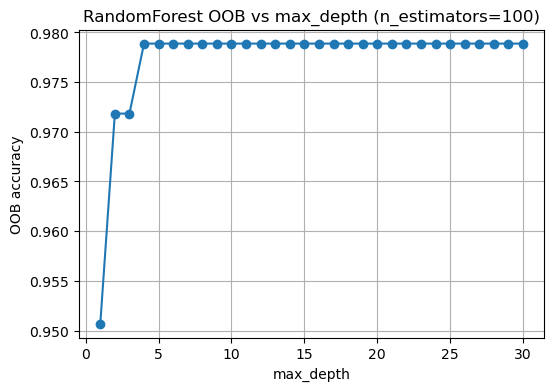

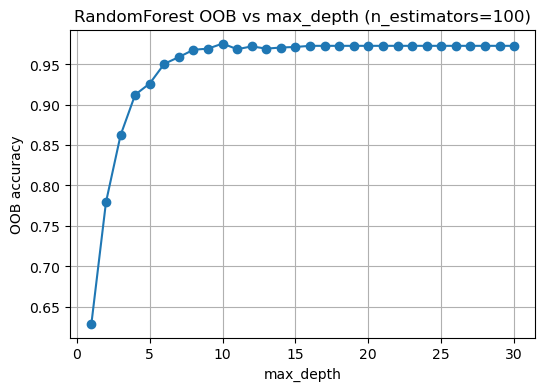

In [51]:
best_depth = []
for Name, X, y in datasets:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    param_rf = {'max_depth': list(range(1, 31)) + [None]}


    oob_scores = []

    for n in param_rf['max_depth']:
        rf = RandomForestClassifier(
            n_estimators = 100,
            max_depth = n,
            max_features='sqrt',
            oob_score = True,
            random_state= 42,
            n_jobs = -1
        )

        rf.fit(X_train, y_train)

        oob = rf.oob_score_

        oob_scores.append(oob)

    b_depth = np.argmax(oob_scores)

    best_depth.append(b_depth)

    depths = param_rf['max_depth']
    plt.figure(figsize=(6,4))
    plt.plot(depths, oob_scores, marker='o')
    plt.xlabel('max_depth')
    plt.ylabel('OOB accuracy')
    plt.title('RandomForest OOB vs max_depth (n_estimators=100)')
    plt.grid(True)
    plt.show()



In [52]:
print(best_depth)

[4, 3, 9]


Define the Goal

You now want to see how tree depth and the number of trees together affect performance.

Intuition:

Shallow trees → high bias (underfit)

Deep trees → high variance (overfit)

More trees → reduced variance (averaging effect)

So this experiment tests whether increasing the number of trees compensates for shallow or deep individual trees.

In [53]:
best_depth_and_size = []
for Name, X, y in datasets:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    param_rf = {
        'max_depth': list(range(1, 21)) + [None],
        'n_estimators': [50, 75, 100, 200, 500]}


    results = []
    depths = param_rf['max_depth']

    for depth in depths:
        for n in param_rf['n_estimators']:
            rf = RandomForestClassifier(
                n_estimators = n,
                max_depth = depth,
                max_features='sqrt',
                oob_score = True,
                random_state= 42,
                n_jobs = -1
            )

            rf.fit(X_train, y_train)

            oob = rf.oob_score_

            results.append({
                'dataset': Name,
                'max_depth': depth if depths else None,
                'n_estimators': n,
                'oob_score': oob
            })

    # Extract all OOB scores into a list
    oob_scores = [r['oob_score'] for r in results]

    # Find the index of the maximum OOB score
    best_idx = np.argmax(oob_scores)

    # Retrieve the corresponding best parameters
    best_result = results[best_idx]
    b_depth = best_result['max_depth']
    b_trees = best_result['n_estimators']

    # Optional: store best depth for later analysis
    best_depth_and_size.append(best_result)

    print(f"Dataset: {Name} | Best depth={b_depth} | Best n_estimators={b_trees} | OOB={best_result['oob_score']:.3f}")


    



Dataset: breast_cancer | Best depth=5 | Best n_estimators=100 | OOB=0.963
Dataset: wine | Best depth=3 | Best n_estimators=200 | OOB=0.979
Dataset: digits | Best depth=15 | Best n_estimators=500 | OOB=0.979


In [54]:
df = pd.DataFrame(best_depth_and_size)
print(df.head())


         dataset  max_depth  n_estimators  oob_score
0  breast_cancer          5           100   0.962637
1           wine          3           200   0.978873
2         digits         15           500   0.979123


Explore impact of different numbers of randomly selected features

fixed values from above:

n_estimators

max_depth

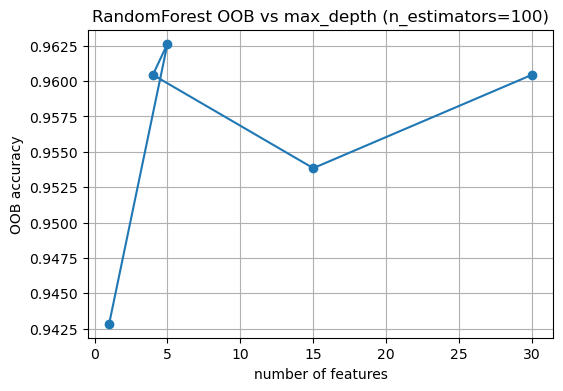

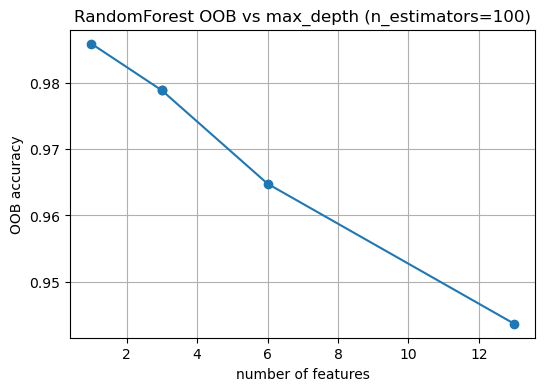

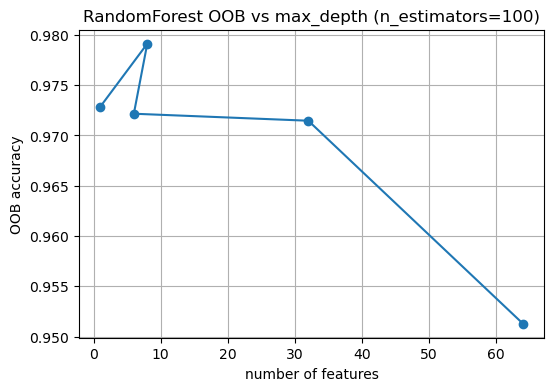

In [55]:
best_num_features = []
for Name, X, y in datasets:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    n_features = X_train.shape[1]
    param_rf = {
        'max_features': [
            1,                          # 1 feature (extremely random)
            int(sqrt(n_features)),      # √p rule
            int(log2(n_features)),      # log₂(p) rule
            int(0.5 * n_features),      # half of all features
            n_features,                 # all features
            None                        # (equivalent to all features)
        ]
    }


    oob_scores = []
    row = df.query("dataset == @Name").iloc[0]
    n_trees = int(row["n_estimators"])
    value = row["max_depth"]
    best_depth = None if pd.isna(value) else int(value)

    for features in param_rf['max_features']:
        rf = RandomForestClassifier(
            n_estimators = n_trees,
            max_depth = best_depth,
            max_features= features,
            oob_score = True,
            random_state= 42,
            n_jobs = -1
        )

        rf.fit(X_train, y_train)

        oob = rf.oob_score_

        oob_scores.append(oob)

    b_num_feat = np.argmax(oob_scores)

    best_num_features.append(b_num_feat)

    feature_rule = param_rf['max_features']
    plt.figure(figsize=(6,4))
    plt.plot(feature_rule, oob_scores, marker='o')
    plt.xlabel('number of features')
    plt.ylabel('OOB accuracy')
    plt.title('RandomForest OOB vs max_depth (n_estimators=100)')
    plt.grid(True)
    plt.show()

In [57]:
best_depth_num_features = []
results = []
for Name, X, y in datasets:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    n_features = X_train.shape[1]
    param_rf = {
        'max_features': [
            1,                          # 1 feature (extremely random)
            int(sqrt(n_features)),      # √p rule
            int(log2(n_features)),      # log₂(p) rule
            int(0.5 * n_features),      # half of all features
            n_features,                 # all features
            None                        # (equivalent to all features)
        ],

        'max_depth': list(range(1, 21)) + [None]
    }


    
    row = df.query("dataset == @Name").iloc[0]
    n_trees = int(row["n_estimators"])
   
    for depth in param_rf['max_depth']:
        for features in param_rf['max_features']:
            rf = RandomForestClassifier(
                n_estimators = n_trees,
                max_depth = depth,
                max_features= features,
                oob_score = True,
                random_state= 42,
                n_jobs = -1
            )

            rf.fit(X_train, y_train)

            oob = rf.oob_score_

            results.append({
                'dataset': Name,
                'max_depth': depth if depths else None,
                'num_param': features,
                'oob_score': oob
            })

    # Extract all OOB scores into a list
    oob_scores = [r['oob_score'] for r in results]

    # Find the index of the maximum OOB score
    best_idx = np.argmax(oob_scores)

    # Retrieve the corresponding best parameters
    best_result = results[best_idx]
    b_depth = best_result['max_depth']
    b_num_param = best_result['num_param']

    # Optional: store best depth for later analysis
    best_depth_num_features.append(best_result)

    print(f"Dataset: {Name} | Best depth={b_depth} | Best number of parameters{b_num_param} | OOB={best_result['oob_score']:.3f}")

Dataset: breast_cancer | Best depth=8 | Best number of parameters1 | OOB=0.969
Dataset: wine | Best depth=2 | Best number of parameters1 | OOB=0.986
Dataset: digits | Best depth=2 | Best number of parameters1 | OOB=0.986
